# Accessing the iCESM Zarr Data Store

This notebook demonstrates how to open and work with preprocessed iCESM water isotope tracer output stored in [zarr](https://zarr.dev/) format on NCAR GDEX (https://gdex.ucar.edu/datasets/d916909/#).

We will:
1. Open a zarr store lazily with `xarray`
2. Select a subset of variables and time steps
3. Load that subset into memory
4. Run two short example analyses (tagged precipitation fraction map, global-mean temperature time series)

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def global_mean_latlon(da):
    """
    Compute the area-weighted global mean for an xarray DataArray with 'lat' and 'lon' dimensions.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with 'lat' and 'lon' dimensions.

    Returns
    -------
    xarray.DataArray
        Area-weighted global mean.
    """
    lat = da['lat']
    weights = np.cos(np.deg2rad(lat))
    weights = weights / weights.sum()

    mean = da.weighted(weights).mean(dim=['lat', 'lon'])
    return mean

## Opening the Zarr Store

`xr.open_zarr()` reads only **metadata** from the store -- coordinate values, dimension sizes, variable attributes, and the chunk layout. No array data is transferred at this stage, so the call returns almost instantly even for stores that are hundreds of GB on disk.

Every data variable in the returned `Dataset` is backed by a **dask array** rather than an in-memory numpy array. Dask arrays are *lazy*: they record the operations you request (slicing, arithmetic, reductions, etc.) but defer the actual computation until you explicitly trigger it with `.compute()`, `.values`, or `.load()`.

Zarr stores are **pre-chunked on disk**, and xarray/dask automatically inherit that chunk structure. This means parallel and out-of-core computation works without any extra configuration -- dask reads and processes one chunk at a time (or many chunks in parallel if you have a distributed scheduler).

In [2]:
PATH_ROOT = 'https://boreas.hpc.ucar.edu:6443/gdex-data/d916909/' #Root GDEX path for NCAR HPC
# PATH_ROOT = 'https://osdf-director.osg-htc.org/ncar-gdex/d916909' #Root GDEX path for remote access

forcing_id = 'iso-piControl' #Define forcing ID (iso-piControl, iso-historical, iso-rcp85)

member_id = None #Define member ID (None, 'r1', 'r2', 'r4', 'r5')

tag_bool = True #Define if tagging is used (True, False)
tag_period_id = None #Define tag period ID (None, 'a', 'b', 'c')

output_frequency = 'mon' #Define output frequency (mon or day)


member_suffix = f'_{member_id}' if member_id is not None else ''
tag_suffix = f'-tag' if tag_bool and tag_period_id is None else f'-tag-{tag_period_id}' if tag_bool else ''

store_name = f'{forcing_id}{member_suffix}{tag_suffix}.{output_frequency}.zarr'
zarr_path = os.path.join(
    PATH_ROOT, forcing_id, store_name
    )

ds_store = xr.open_dataset(zarr_path, engine='zarr', consolidated=True)

Printing the dataset below shows that each variable is a **dask array** with shape and chunk information displayed -- no data has been loaded into memory yet.

In [3]:
print(ds_store)

<xarray.Dataset> Size: 261GB
Dimensions:          (time: 360, lat: 192, lon: 288, lev: 30, ilev: 31)
Coordinates:
  * time             (time) object 3kB 0001-01-01 00:00:00 ... 0030-12-01 00:...
  * lat              (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon              (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev              (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev             (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
Data variables: (12/380)
    AEROD_v          (time, lat, lon) float32 80MB ...
    ANRAIN           (time, lev, lat, lon) float32 2GB ...
    ANSNOW           (time, lev, lat, lon) float32 2GB ...
    AREI             (time, lev, lat, lon) float32 2GB ...
    AREL             (time, lev, lat, lon) float32 2GB ...
    AWNC             (time, lev, lat, lon) float32 2GB ...
    ...               ...
    TREFHT           (time, lat, lon) float32 80MB ...
    TS               (time, l

In [4]:
print(f'Total store size: {ds_store.nbytes / 1e9:.2f} GB')

Total store size: 260.78 GB


## Selecting Data and Loading to Memory

The full store above is ~260 GB, far more than available RAM. The recommended workflow is:

1. **Select** only the variables and time range you need (these operations are free since the data is still lazy).
2. **Call `.compute()`** to trigger dask to read the selected chunks from disk and assemble them into in-memory numpy arrays.

Compare the size of the loaded subset to the full store to see how much memory you actually use.

> **Performance tip:** Data access is most efficient when your selection aligns with the store's chunk boundaries. Each chunk is the smallest unit that dask reads from disk -- if your slice crosses a chunk boundary, dask must read the entire neighboring chunk and then discard the unused portion. You can inspect the chunk layout in the dataset summary printed above and, when possible, choose time/spatial slices that fall on chunk edges.

In [5]:
# Select a subset of variables
tag_id = 'LAT25N'
variables = [
    'PRECC', 'PRECL', 'PRECSC', 'PRECSL',
    f'PRECRC_{tag_id}r', f'PRECRL_{tag_id}R', f'PRECSC_{tag_id}s', f'PRECSL_{tag_id}S',
    ]
ds = ds_store[variables]

# Select a subset of time steps
ds = ds.isel(time=slice(12,None))

# Load the selected data into memory
ds = ds.compute()

print(ds)

<xarray.Dataset> Size: 616MB
Dimensions:         (time: 348, lat: 192, lon: 288)
Coordinates:
  * time            (time) object 3kB 0002-01-01 00:00:00 ... 0030-12-01 00:0...
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    PRECC           (time, lat, lon) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    PRECL           (time, lat, lon) float32 77MB 7.49e-10 ... 8.412e-09
    PRECSC          (time, lat, lon) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    PRECSL          (time, lat, lon) float32 77MB 7.49e-10 ... 8.407e-09
    PRECRC_LAT25Nr  (time, lat, lon) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    PRECRL_LAT25NR  (time, lat, lon) float32 77MB 4.552e-27 ... 6.435e-14
    PRECSC_LAT25Ns  (time, lat, lon) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    PRECSL_LAT25NS  (time, lat, lon) float32 77MB 5.112e-13 ... 4.025e-10
Attributes:
    Conventions:       CF-1.0
    

In [6]:
print(f'Loaded subset size: {ds.nbytes / 1e9:.2f} GB')

Loaded subset size: 0.62 GB


## Example: Tagged Precipitation Fraction

Water isotope tagging tracks moisture from a source region through the atmosphere. Here we compute the **time-integrated fraction** of total precipitation that originated from the `LAT25N` tagging region:

$$\text{fraction} = \frac{\sum_t P_{\text{tag}}(t)}{\sum_t P_{\text{bulk}}(t)}$$

where the bulk and tagged precipitation each combine convective and large-scale (rain + snow) components.

In [7]:
pr_bulk = ds['PRECC'] + ds['PRECL'] + ds['PRECSC'] + ds['PRECSL']
pr_tag = ds[f'PRECRC_{tag_id}r'] + ds[f'PRECRL_{tag_id}R'] + ds[f'PRECSC_{tag_id}s'] + ds[f'PRECSL_{tag_id}S']
pr_mean_frac = pr_tag.sum(dim='time') / pr_bulk.sum(dim='time')

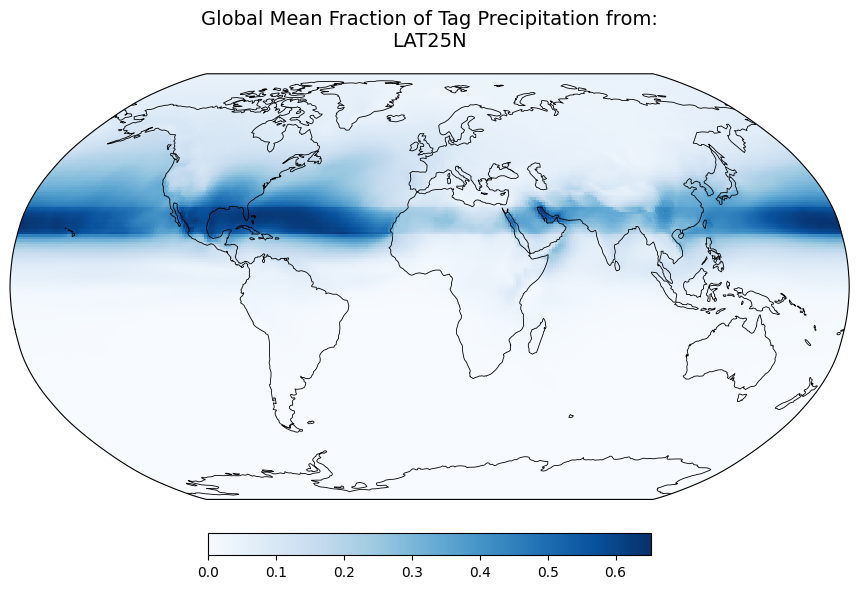

In [8]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

plot_max = pr_mean_frac.max().values

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.coastlines(linewidth=0.6)

lons = ds['lon'].values
lats = ds['lat'].values
lon2d, lat2d = np.meshgrid(lons, lats)

cmap = plt.get_cmap('Blues')

im = ax.pcolormesh(
    lon2d, lat2d, 
    pr_mean_frac.values, 
    transform=ccrs.PlateCarree(), 
    cmap=cmap, 
    vmin=0, vmax=plot_max,
)

cb = plt.colorbar(im, orientation='horizontal', pad=0.07, fraction=0.046)

ax.set_title(f'Global Mean Fraction of Tag Precipitation from:\n{tag_id}', fontsize=14, pad=20)

plt.tight_layout()

## Example: Global-Mean Temperature Time Series

This example demonstrates keeping the computation **lazy** through intermediate steps. We select a single variable (`TREFHT` -- near-surface air temperature), apply an area-weighted global mean, and only call `.compute()` at the very end. Dask builds a task graph for the entire chain and executes it in one pass, reading only the chunks it needs.

In [9]:
tas = ds_store['TREFHT']
tas_global_mean = global_mean_latlon(tas)
print(tas_global_mean)

<xarray.DataArray 'TREFHT' (time: 360)> Size: 3kB
array([284.28429944, 284.77365928, 285.38962176, 286.32230845,
       287.25716257, 288.09422312, 288.30495661, 288.0893625 ,
       287.24849941, 286.09079514, 284.89007126, 284.37902967,
       284.15285105, 284.58027381, 285.16489104, 286.27130093,
       287.07749632, 287.81838571, 288.07066693, 287.9724303 ,
       287.25795575, 286.06957531, 284.78995531, 284.16652982,
       284.04019289, 284.47552735, 285.18543208, 286.29638539,
       287.1671037 , 287.87832697, 288.14296397, 288.08560318,
       287.32149363, 286.11006876, 284.98777925, 284.2528317 ,
       284.18210597, 284.60198651, 285.27381196, 286.28247527,
       287.25680281, 287.98841312, 288.26842789, 288.14298915,
       287.27868584, 286.23978331, 284.8596089 , 284.2450689 ,
       284.0884749 , 284.47879724, 285.35871182, 286.13486188,
       287.19257031, 287.86337339, 288.28608022, 287.98777906,
       287.2272022 , 285.93669339, 284.85530427, 283.9761376 ,
     

In [10]:
tas_global_mean = tas_global_mean.compute()
print(tas_global_mean)

<xarray.DataArray 'TREFHT' (time: 360)> Size: 3kB
array([284.28429944, 284.77365928, 285.38962176, 286.32230845,
       287.25716257, 288.09422312, 288.30495661, 288.0893625 ,
       287.24849941, 286.09079514, 284.89007126, 284.37902967,
       284.15285105, 284.58027381, 285.16489104, 286.27130093,
       287.07749632, 287.81838571, 288.07066693, 287.9724303 ,
       287.25795575, 286.06957531, 284.78995531, 284.16652982,
       284.04019289, 284.47552735, 285.18543208, 286.29638539,
       287.1671037 , 287.87832697, 288.14296397, 288.08560318,
       287.32149363, 286.11006876, 284.98777925, 284.2528317 ,
       284.18210597, 284.60198651, 285.27381196, 286.28247527,
       287.25680281, 287.98841312, 288.26842789, 288.14298915,
       287.27868584, 286.23978331, 284.8596089 , 284.2450689 ,
       284.0884749 , 284.47879724, 285.35871182, 286.13486188,
       287.19257031, 287.86337339, 288.28608022, 287.98777906,
       287.2272022 , 285.93669339, 284.85530427, 283.9761376 ,
     

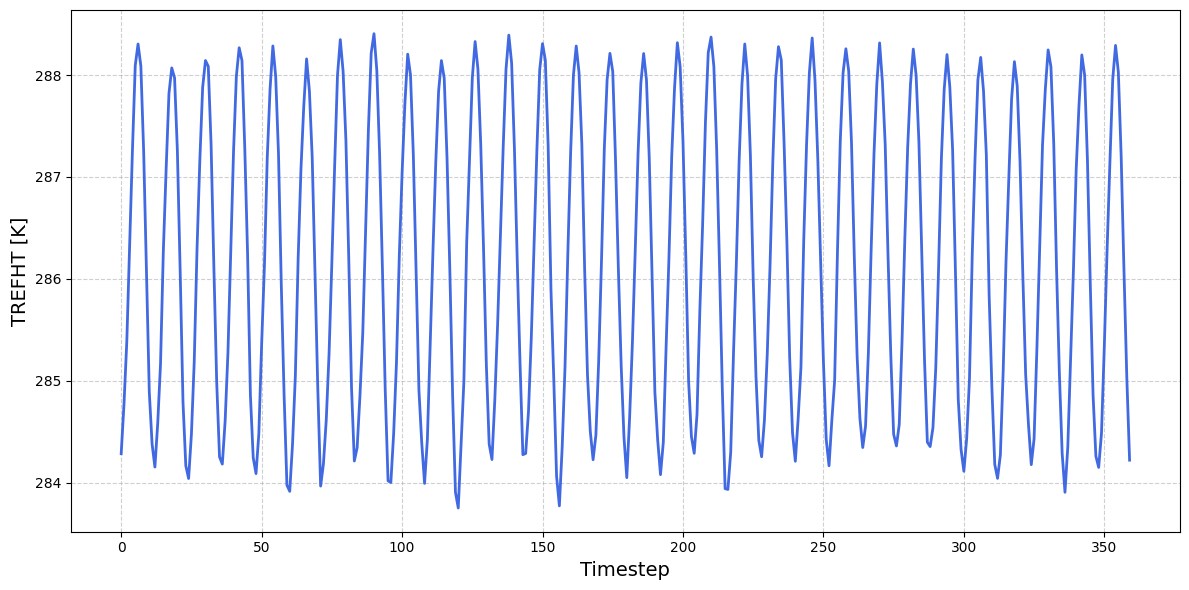

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
try:
    plt.plot(tas_global_mean['time'], tas_global_mean, color='royalblue', linewidth=2)
    plt.xlabel('Time', fontsize=14)
except TypeError:
    plt.plot(tas_global_mean, color='royalblue', linewidth=2)
    plt.xlabel('Timestep', fontsize=14)

plt.ylabel(f"TREFHT [{tas_global_mean.attrs.get('units', '')}]", fontsize=14)
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()